**Topic Classification**

1.Wordcloud

2.LDA label comments

3.Machine learning

4.Ensemble method

5.TextCNN

6.Comparison

In [220]:
import pandas as pd
import numpy as np
import jieba
import jieba.analyse
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# LDA相关
import gensim
from gensim import corpora, models
from gensim.models import LdaModel, CoherenceModel

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 机器学习分类模型
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import itertools
import re
from gensim import corpora, models
from gensim.models import LdaModel, CoherenceModel

# 深度学习模型
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [221]:
df = pd.read_excel('AllCameras_Cleaned.xlsx')
df.head()

,用户ID,时间,商品规格,评论内容,页面标题,品牌
0,33i874m08mg70a,2025-12-30,R50 黑色 R50 18-45镜头套机,前前后后看了一个月比较各款入门相机，最后选定佳能，买的套头，产品包装严实，完整，三马合一。虽...,【佳能EOS R50】佳能（Canon）R50微单相机 旅行拍照摄影专用照相机 4K高清视频...,佳能
1,j***9,2025-12-30,R50黑色 RF-S18-45套机 官方标配【京东多仓发~快可次日达】,真的跟小巧，拿起来也不会很累手，拍照也很好看，比手机出片多啊，真的佳能感动常在，真的很合适入...,佳能（Canon）EOS R50 微单半画幅相机 r50小巧便携 Vlog拍摄直播相机 4K...,佳能
2,yuhong012,2025-12-30,R50 黑色 R50 18-45镜头套机,发货迅速已经收到货了，商品和描述的差不多，质量没问题，价格合适，在这里买很放心！,【佳能EOS R50】佳能（Canon）R50微单相机 旅行拍照摄影专用照相机 4K高清视频...,佳能
3,jd_152551ubv,2025-12-30,R50 白色 R50 18-45镜头套机,颜值高，价格优惠，挺划算的，好用,【佳能EOS R50】佳能（Canon）R50微单相机 旅行拍照摄影专用照相机 4K高清视频...,佳能
4,limrong,2025-12-30,R50白色 RF-S18-45套机 套餐五【256G高速卡~高容双电池~高端三脚架】,对新手很友好，拍照效果不错，套机焦距可调，套餐搭配很多东西。,佳能（Canon）EOS R50 微单半画幅相机 r50小巧便携 Vlog拍摄直播相机 4K...,佳能


In [222]:
# 加载停用词
def load_stopwords(file_path='stopWord.txt'):
    """从文件中读取停用词"""
    stopwords = set()
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                word = line.strip()
                if word:  
                    stopwords.add(word)
    except:
        print("未找到stopWord.txt文件，使用默认停用词")
        stopwords = {'的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '一个', 
                     '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', '自己',
                     '这', '那', '什么', '怎么', '吧', '啊', '呀', '哦', '嗯', '哈哈', '呵呵', '京东',
                     '官方', '标配', '黑色', '白色', '套机', '镜头', '包装', '发货'}
    return stopwords

# 加载停用词
stopwords = load_stopwords('stopWord.txt')

# 手动添加"相机"到停用词
#stopwords.add('相机')

# 添加自定义词典（注意：自定义词典中不要包含"相机"，因为已经作为停用词了）
custom_words = ['佳能', '索尼', '尼康', '富士', '拍照', '摄影', '微单', '单反', 
                '对焦', '画质', '夜景', '人像', '风景']

for word in custom_words:
    jieba.add_word(word)

def chinese_word_segment(text):
    """中文分词函数"""
    if pd.isna(text):
        return ""
    
    # 分词
    words = jieba.cut(str(text))
    
    # 去除停用词和单字词
    words = [word for word in words if word not in stopwords and len(word) > 1]
    
    return ' '.join(words)

# 对评论进行分词（保留为字符串用于TF-IDF）
df['segmented_text'] = df['评论内容'].apply(chinese_word_segment)

# 同时保留分词列表用于LDA
df['segmented_list'] = df['segmented_text'].apply(lambda x: x.split())

print(f"总样本数: {len(df)}")
print(f"品牌分布:\n{df['品牌'].value_counts()}")

# 查看分词结果示例，确认"相机"已被去除
for i in range(min(3, len(df))):
    print(f"原始评论: {df.iloc[i]['评论内容'][:80]}...")
    print(f"分词结果: {df.iloc[i]['segmented_text'][:100]}...")
    print()

总样本数: 4170
品牌分布:
品牌
佳能    1286
尼康    1062
索尼     940
富士     882
Name: count, dtype: int64
原始评论: 前前后后看了一个月比较各款入门相机，最后选定佳能，买的套头，产品包装严实，完整，三马合一。虽然港水更便宜，还是官方更放心，接下来就是提高摄影技术了...
分词结果: 前前后后 一个月 比较 各款 入门 相机 最后 选定 佳能 套头 产品包装 严实 完整 三马 合一 港水 便宜 官方 放心 提高 摄影 技术...

原始评论: 真的跟小巧，拿起来也不会很累手，拍照也很好看，比手机出片多啊，真的佳能感动常在，真的很合适入手，操作也比较简单...
分词结果: 真的 小巧 累手 拍照 好看 手机 出片 真的 佳能 感动 常在 真的 合适 入手 操作 比较简单...

原始评论: 发货迅速已经收到货了，商品和描述的差不多，质量没问题，价格合适，在这里买很放心！...
分词结果: 发货 迅速 已经 收到 商品 描述 质量 问题 价格 合适 放心...



## 1.wordcloud

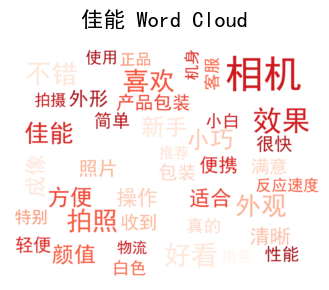

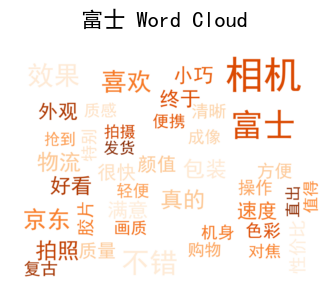

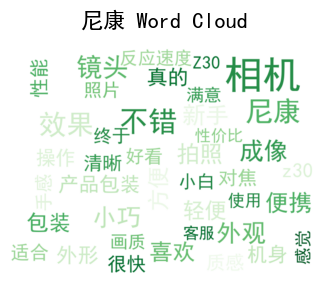

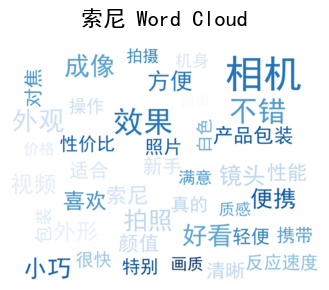

In [223]:
# 定义品牌颜色方案
brand_colors = {
    '佳能': '#fa7e7e',  # 红色系
    '索尼': '#7ec8fa',  # 蓝色系
    '尼康': '#7efa9e',  # 绿色系
    '富士': '#faca7e'   # 橙色系
}

# 定义品牌对应的词云颜色映射
brand_color_maps = {
    '佳能': 'Reds',
    '索尼': 'Blues',
    '尼康': 'Greens',
    '富士': 'Oranges'
}

def generate_wordcloud_by_brand(df, brand_name, color_map=None, max_words=40):
    """
    为指定品牌生成词云图
    """
    # 合并该品牌所有评论的分词
    brand_df = df[df['品牌'] == brand_name]
    
    if len(brand_df) == 0:
        print(f"{brand_name} 没有数据")
        return
    
    # 获取所有分词并合并成文本
    all_words = []
    for words in brand_df['segmented_list']:
        all_words.extend(words)
    
    if not all_words:
        print(f"{brand_name} 没有有效的分词结果")
        return
    
    # 统计词频，只取前30个词
    word_freq = Counter(all_words)
    top_words = dict(word_freq.most_common(max_words))
    
    # 生成词云
    if color_map:
        wordcloud = WordCloud(
            width=800,
            height=600,
            background_color='white',
            font_path='simhei.ttf',
            colormap=color_map,
            max_words=max_words,
            min_font_size=10,
            max_font_size=100,
            random_state=42,
            relative_scaling=0.5
        ).generate_from_frequencies(top_words)
    else:
        wordcloud = WordCloud(
            width=800,
            height=600,
            background_color='white',
            font_path='simhei.ttf',
            max_words=max_words,
            min_font_size=10,
            max_font_size=100,
            random_state=42,
            relative_scaling=0.5
        ).generate_from_frequencies(top_words)
    
    # 绘制
    plt.figure(figsize=(4, 3))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{brand_name} Word Cloud', fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(f'{brand_name}_wordcloud.png', dpi=300, bbox_inches='tight')
    plt.show()

# 为每个品牌生成词云图
for brand in df['品牌'].unique():
    # 获取该品牌对应的颜色映射
    color_map = brand_color_maps.get(brand, 'viridis')
    # 生成词云图
    generate_wordcloud_by_brand(df, brand, color_map=color_map, max_words=40)

## 2.LDA label comments

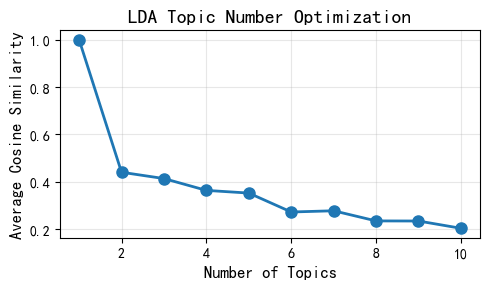

In [224]:
# 构造主题数寻优函数
def cos(vector1, vector2):
    '''
    函数功能：余弦相似度函数
    '''
    dot_product = 0.0
    normA = 0.0
    normB = 0.0
    for a, b in zip(vector1, vector2):
        dot_product += a * b
        normA += a ** 2
        normB += b ** 2
    if normA == 0.0 or normB == 0.0:
        return None
    else:
        return (dot_product / ((normA * normB) ** 0.5))

def LDA_k(x_corpus, x_dict, max_topics=10):
    '''
    函数功能：计算不同主题数下的平均余弦相似度
    '''
    # 初始化平均余弦相似度
    mean_similarity = []
    mean_similarity.append(1)  # 主题数为1时的相似度设为1
    
    # 循环生成主题并计算主题间相似度
    for i in np.arange(2, max_topics + 1):
        # LDA模型训练
        lda = models.LdaModel(
            x_corpus, 
            num_topics=i, 
            id2word=x_dict,
            random_state=42,
            passes=10
        )
        
        # 提取各主题词（每个主题取前50个词）
        term = lda.show_topics(num_topics=i, num_words=50, formatted=False)
        
        # 提取各主题词列表
        top_word = []  # shape=(i,50)
        for k in range(i):
            words = [word for word, _ in term[k][1]]
            top_word.append(words)
        
        # 构造词频向量
        word = sum(top_word, [])  # 列出所有词
        unique_word = set(word)  # 去重
        
        # 构造主题词矩阵，行表示主题号，列表示各主题词
        mat = []  # shape=(i, len(unique_word))
        for j in range(i):
            top_w = top_word[j]
            # 统计每个词在当前主题中出现的次数
            mat.append(tuple([top_w.count(k) for k in unique_word]))
        
        # 两两组合计算相似度
        p = list(itertools.permutations(list(np.arange(i)), 2))
        y = len(p)  # y = i*(i-1)
        top_similarity = []
        
        for w in range(y):
            vector1 = mat[p[w][0]]
            vector2 = mat[p[w][1]]
            similarity = cos(vector1, vector2)
            if similarity is not None:
                top_similarity.append(similarity)
        
        # 计算平均余弦相似度
        if top_similarity:
            mean_similarity.append(sum(top_similarity) / len(top_similarity))
        else:
            mean_similarity.append(1)
    
    return mean_similarity

# 准备数据
texts = df['segmented_list'].tolist()
texts = [text for text in texts if text]

# 创建字典和语料库
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.8)
corpus = [dictionary.doc2bow(text) for text in texts]

# 执行主题数寻优
mean_similarity = LDA_k(corpus, dictionary, max_topics=10)

# 可视化结果
plt.figure(figsize=(5, 3))
plt.plot(range(1, 11), mean_similarity, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Topics', fontsize=12)
plt.ylabel('Average Cosine Similarity', fontsize=12)
plt.title('LDA Topic Number Optimization', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('topic_number_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

In [225]:
# 使用寻优得到的最佳主题数
best_num_topics = 4 

# 训练最终的LDA模型
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    random_state=42,
    passes=20,
    alpha='auto',
    per_word_topics=True
)

# 计算一致性分数
coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"模型一致性分数: {coherence_score:.4f}")

# 提取每个主题的关键词
topics_dict = {}
print("\n" + "="*60)
print(f"LDA主题分析结果 (主题数: {best_num_topics})")
print("="*60)

for idx in range(best_num_topics):
    topic_words = lda_model.show_topic(idx, topn=15)
    topics_dict[idx] = topic_words
    
    print(f"\n主题 {idx}:")
    print("-" * 40)
    for word, weight in topic_words:
        print(f"  {word}: {weight:.6f}")


模型一致性分数: 0.4999

LDA主题分析结果 (主题数: 4)

主题 0:
----------------------------------------
  效果: 0.052311
  成像: 0.046242
  外观: 0.044477
  外形: 0.036990
  便携: 0.035350
  性能: 0.031443
  产品包装: 0.030088
  反应速度: 0.025927
  不错: 0.023027
  小巧: 0.020054
  包装: 0.018488
  好看: 0.016866
  方便: 0.016661
  很快: 0.015348
  携带: 0.013807

主题 1:
----------------------------------------
  相机: 0.025542
  视频: 0.023621
  对焦: 0.019651
  清晰: 0.014834
  索尼: 0.014546
  操作: 0.014342
  小巧: 0.013853
  画质: 0.013286
  拍摄: 0.012878
  机身: 0.012322
  新手: 0.011455
  适合: 0.011218
  简单: 0.010849
  效果: 0.010579
  轻便: 0.010393

主题 2:
----------------------------------------
  相机: 0.044276
  不错: 0.022686
  喜欢: 0.015684
  满意: 0.013925
  物流: 0.011967
  拍照: 0.011647
  包装: 0.011182
  终于: 0.010235
  客服: 0.010216
  收到: 0.010148
  推荐: 0.009577
  京东: 0.009373
  正品: 0.008774
  很快: 0.008629
  颜值: 0.007919

主题 3:
----------------------------------------
  镜头: 0.026886
  相机: 0.026267
  好看: 0.017403
  喜欢: 0.013654
  真的: 0.013633
  小巧: 0.013250
  拍

In [226]:
# 定义主题标签
topic_labels = {
    0: "Design & Portability",
    1: "Performance & Quality", 
    2: "Appearance & Satisfaction",
    3: "Logistics & Service"
}

def assign_topics_to_all_comments(df, lda_model, dictionary):
    """为所有评论分配主题"""
    topic_assignments = []
    
    for idx, row in df.iterrows():
        words = row['segmented_list']
        if not words:
            topic_assignments.append(-1)
            continue
        
        # 转换为bow
        bow = dictionary.doc2bow(words)
        
        # 获取主题分布
        topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
        
        # 找到概率最高的主题
        if topic_dist:
            main_topic = max(topic_dist, key=lambda x: x[1])[0]
            topic_assignments.append(main_topic)
        else:
            topic_assignments.append(-1)
    
    return topic_assignments

# 分配主题
df['topic_id'] = assign_topics_to_all_comments(df, lda_model, dictionary)
df['topic_label'] = df['topic_id'].map(topic_labels)
df.head()

# 查看分配结果
print("\n主题分布统计:")
print(df['topic_label'].value_counts())
print(f"\n各品牌主题分布:")
print(pd.crosstab(df['品牌'], df['topic_label']))

# 统计每个主题的样本数量
print("\n各主题样本数量统计:")
print(df['topic_label'].value_counts())

# 统计每个主题的占比
print("\n各主题样本占比:")
print(df['topic_label'].value_counts(normalize=True).map(lambda x: f"{x:.2%}"))

# 保存标注后的表格
df.to_csv('camera_labeled.csv', index=False, encoding='utf-8-sig')


主题分布统计:
topic_label
Appearance & Satisfaction    1712
Logistics & Service           956
Performance & Quality         767
Design & Portability          732
Name: count, dtype: int64

各品牌主题分布:
topic_label  Appearance & Satisfaction  Design & Portability  \
品牌                                                             
佳能                                 643                   245   
富士                                 454                    74   
尼康                                 338                   189   
索尼                                 277                   224   

topic_label  Logistics & Service  Performance & Quality  
品牌                                                       
佳能                           199                    199  
富士                           137                    215  
尼康                           379                    156  
索尼                           241                    197  

各主题样本数量统计:
topic_label
Appearance & Satisfaction    1712
Logistics & Serv

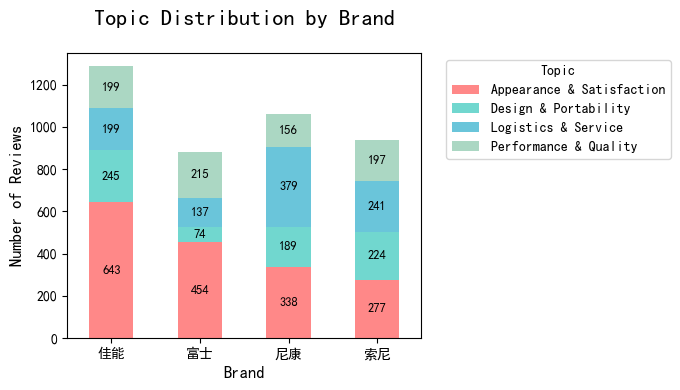

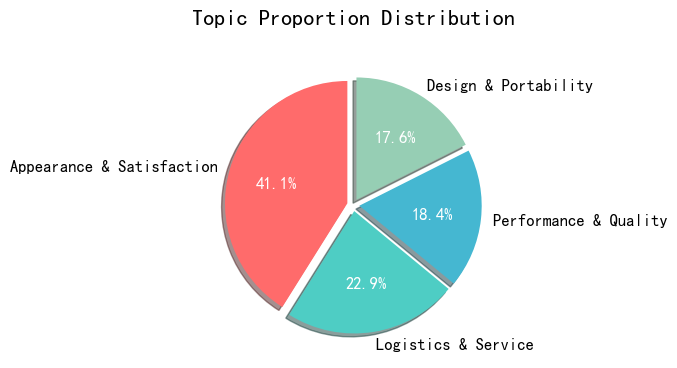

In [227]:
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 图1：各品牌主题分布（堆叠柱状图）
# 创建交叉表
brand_topic_crosstab = pd.crosstab(df['品牌'], df['topic_label'])

# 设置颜色
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# 绘制堆叠柱状图
fig, ax = plt.subplots(figsize=(7, 4))

# 绘制堆叠柱状图
brand_topic_crosstab.plot(kind='bar', stacked=True, ax=ax, color=colors, alpha=0.8)

# 添加数值标签
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=9)

plt.title('Topic Distribution by Brand', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('brand_topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 图2：各主题样本占比饼图
# 计算主题占比
topic_counts = df['topic_label'].value_counts()
topic_percentages = topic_counts / topic_counts.sum() * 100

# 设置颜色和样式
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
explode = (0.05, 0.05, 0.05, 0.05) 

# 绘制饼图
fig, ax = plt.subplots(figsize=(6, 5))

wedges, texts, autotexts = ax.pie(topic_counts, 
                                   explode=explode,
                                   labels=topic_counts.index,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   shadow=True,
                                   textprops={'fontsize': 12})

# 美化百分比文本
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.title('Topic Proportion Distribution', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('topic_percentage_pie.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.Machine learning

In [228]:
# 从你的数据中构造X和y
X = df['segmented_text'].values
y = df['topic_id'].values

# 过滤掉未分配主题的样本
mask = y != -1
X = X[mask]
y = y[mask]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF向量化
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [229]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_tfidf, y_train)

# 预测
y_pred_logistic = logistic_model.predict(X_test_tfidf)

# 评估
print("=== Logistic Regression ===")
print(metrics.classification_report(y_test, y_pred_logistic))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_logistic):.4f}')
print(f'Weighted Precision: {metrics.precision_score(y_test, y_pred_logistic, average="weighted"):.4f}')
print(f'Weighted Recall: {metrics.recall_score(y_test, y_pred_logistic, average="weighted"):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_logistic, average="weighted"):.4f}')

# 混淆矩阵
print("\nConfusion Matrix:")
print(pd.crosstab(y_test, y_pred_logistic, margins=True))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       146
           1       0.89      0.75      0.81       154
           2       0.80      0.92      0.86       343
           3       0.74      0.73      0.74       191

    accuracy                           0.83       834
   macro avg       0.85      0.81      0.83       834
weighted avg       0.84      0.83      0.83       834

Accuracy: 0.8285
Weighted Precision: 0.8352
Weighted Recall: 0.8285
Weighted F1-score: 0.8281

Confusion Matrix:
col_0    0    1    2    3  All
row_0                         
0      120    2   14   10  146
1        1  116   20   17  154
2        1    5  316   21  343
3        1    8   43  139  191
All    123  131  393  187  834


In [230]:
from sklearn.naive_bayes import MultinomialNB

# 训练朴素贝叶斯模型
nb_model = MultinomialNB(alpha = 0.2)
nb_model.fit(X_train_tfidf, y_train)

# 预测
y_pred_nb = nb_model.predict(X_test_tfidf)

# 评估
print("=== Naive Bayes ===")
print(metrics.classification_report(y_test, y_pred_nb))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_nb):.4f}')
print(f'Weighted Precision: {metrics.precision_score(y_test, y_pred_nb, average="weighted"):.4f}')
print(f'Weighted Recall: {metrics.recall_score(y_test, y_pred_nb, average="weighted"):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_nb, average="weighted"):.4f}')

# 混淆矩阵
print("\nConfusion Matrix:")
print(pd.crosstab(y_test, y_pred_nb, margins=True))

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       146
           1       0.85      0.74      0.79       154
           2       0.81      0.92      0.86       343
           3       0.76      0.74      0.75       191

    accuracy                           0.82       834
   macro avg       0.84      0.80      0.82       834
weighted avg       0.83      0.82      0.82       834

Accuracy: 0.8237
Weighted Precision: 0.8283
Weighted Recall: 0.8237
Weighted F1-score: 0.8227

Confusion Matrix:
col_0    0    1    2    3  All
row_0                         
0      116    3   19    8  146
1        4  114   18   18  154
2        0    9  315   19  343
3        3    8   38  142  191
All    123  134  390  187  834


In [231]:
from sklearn.tree import DecisionTreeClassifier

# 训练决策树模型
dt_model = DecisionTreeClassifier(
    max_depth=None, 
    min_samples_split=10,      
    min_samples_leaf=3,     
    criterion='gini',   
    splitter='best',
    random_state=42
)
dt_model.fit(X_train_tfidf, y_train)

# 预测
y_pred_dt = dt_model.predict(X_test_tfidf)

# 评估
print("=== Decision Tree ===")
print(metrics.classification_report(y_test, y_pred_dt))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Weighted Precision: {metrics.precision_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'Weighted Recall: {metrics.recall_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_dt, average="weighted"):.4f}')

# 混淆矩阵
print("\nConfusion Matrix:")
print(pd.crosstab(y_test, y_pred_dt, margins=True))

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       146
           1       0.54      0.52      0.53       154
           2       0.70      0.69      0.69       343
           3       0.49      0.51      0.50       191

    accuracy                           0.62       834
   macro avg       0.61      0.61      0.61       834
weighted avg       0.62      0.62      0.62       834

Accuracy: 0.6223
Weighted Precision: 0.6223
Weighted Recall: 0.6223
Weighted F1-score: 0.6221

Confusion Matrix:
col_0    0    1    2    3  All
row_0                         
0      106    9   20   11  146
1       13   80   30   31  154
2       24   26  236   57  343
3       10   32   52   97  191
All    153  147  338  196  834


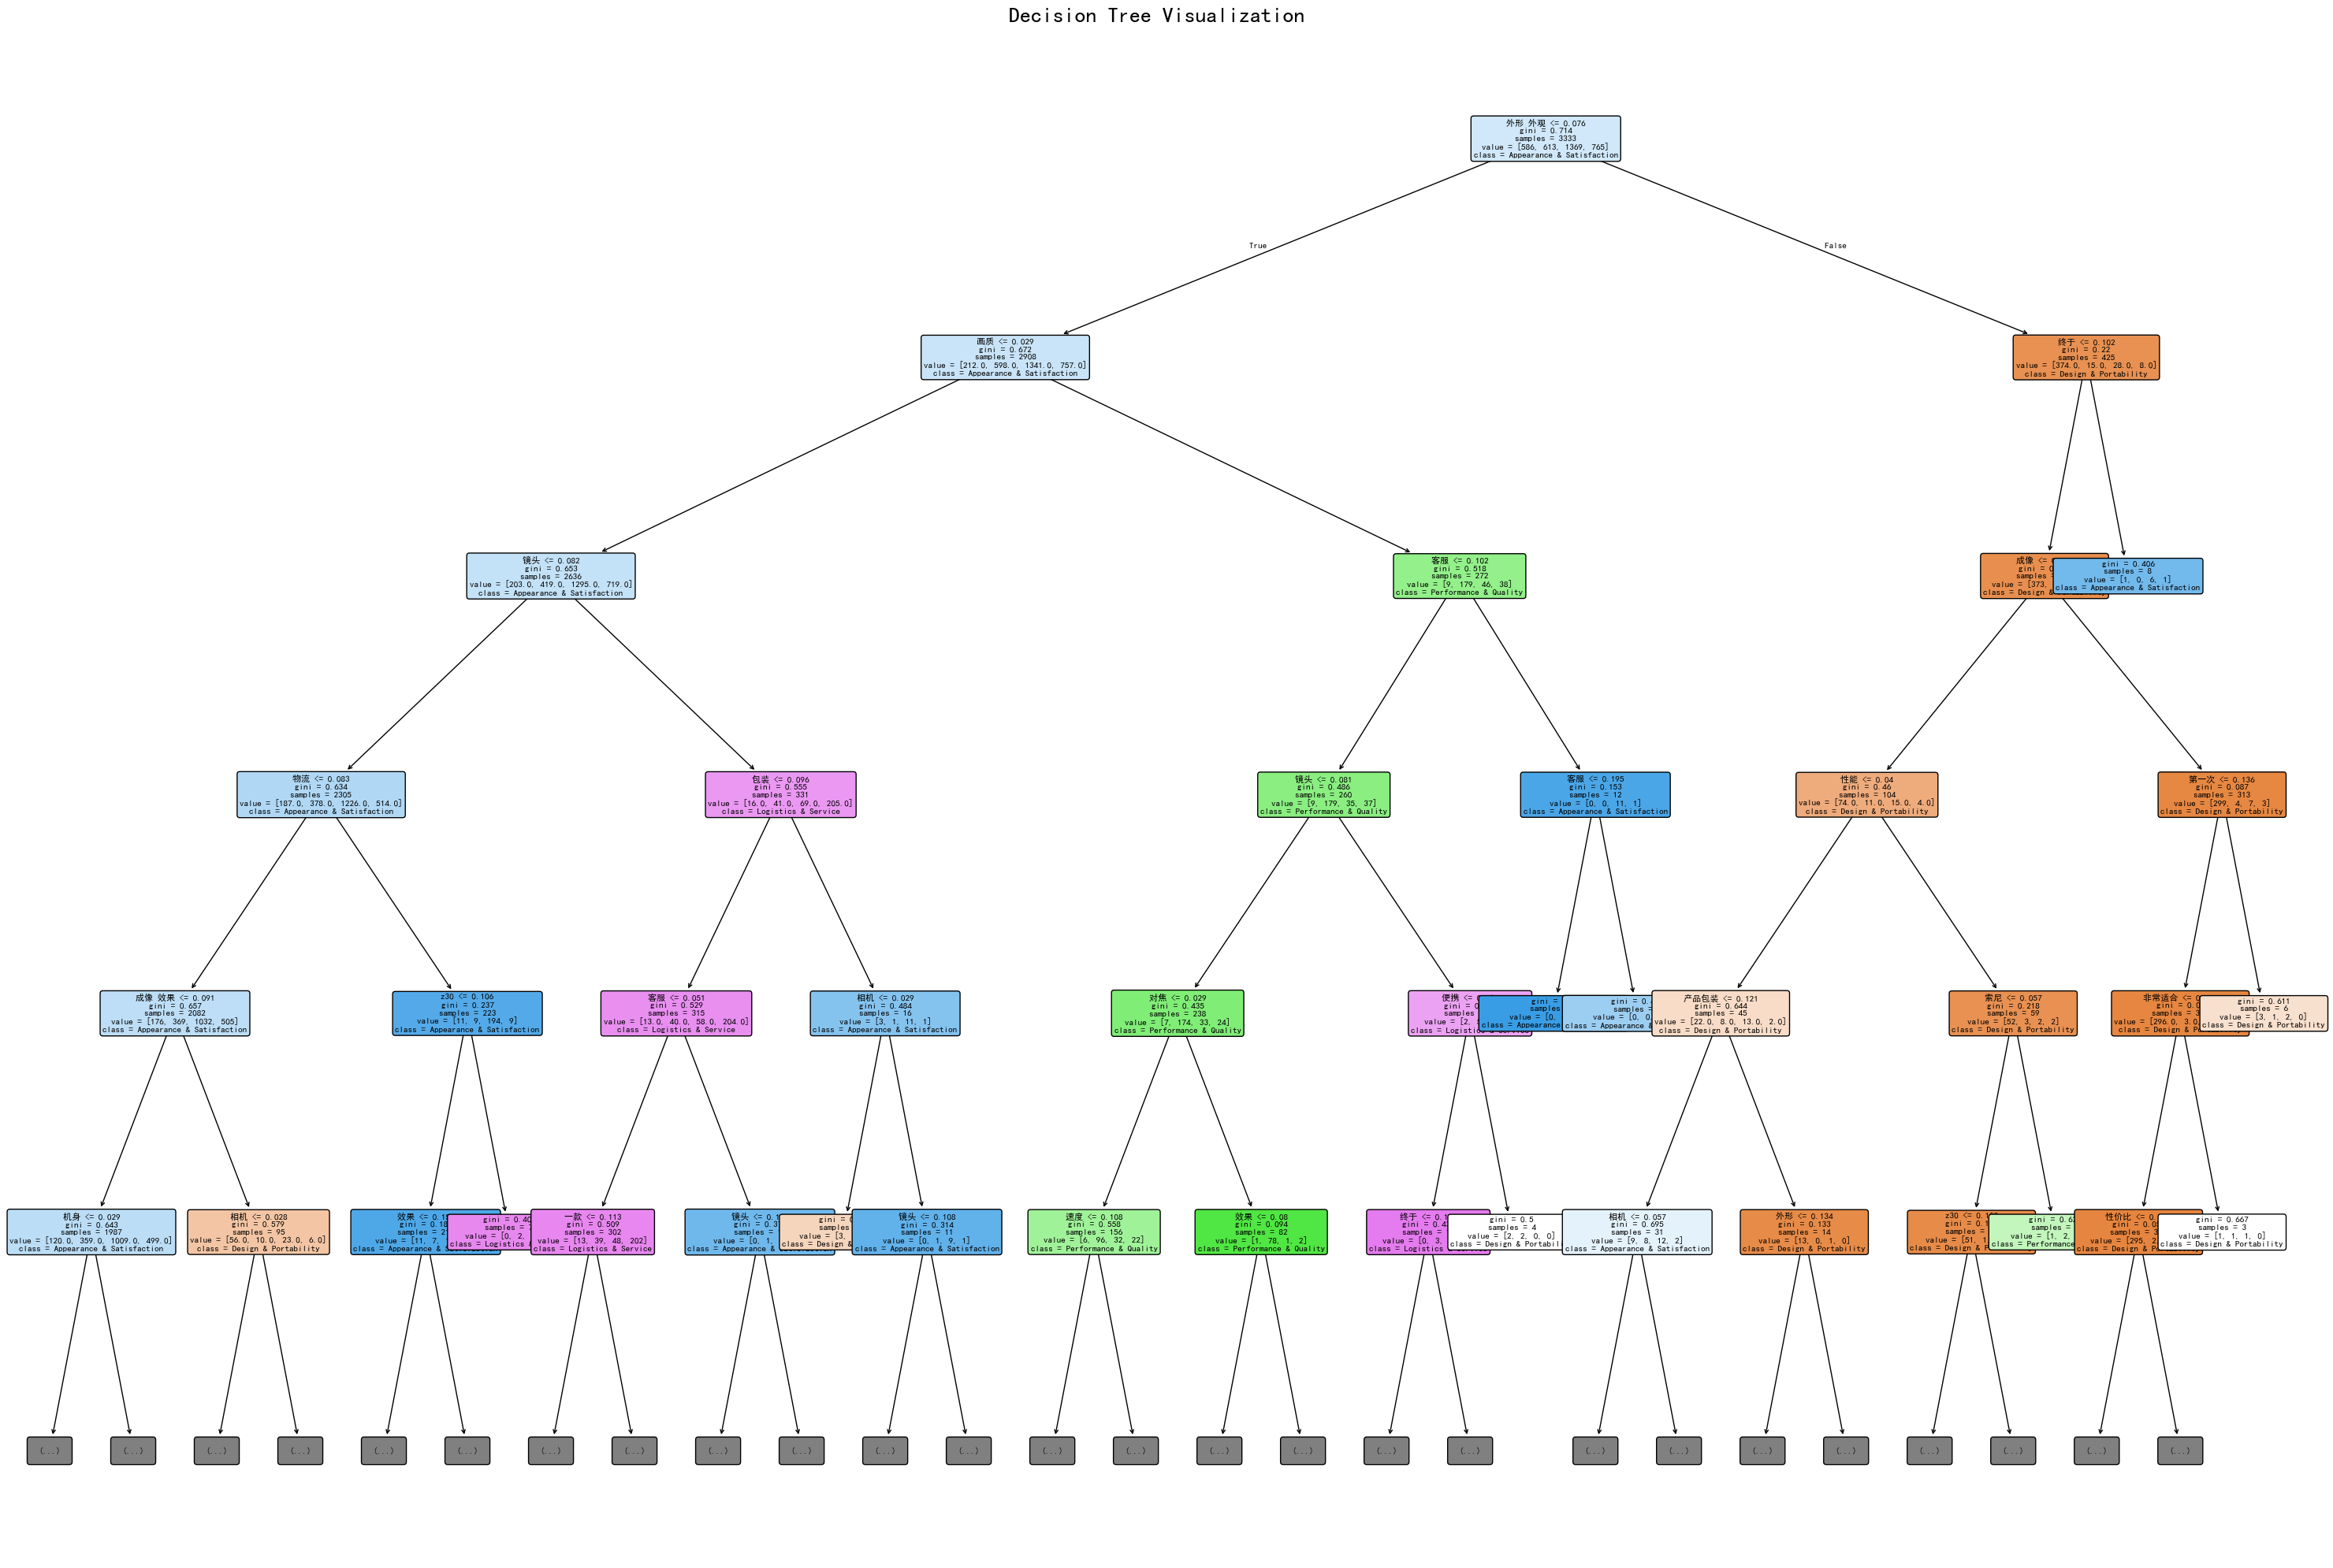

In [232]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 获取特征名称
feature_names = tfidf_vectorizer.get_feature_names_out()

# 获取类别名称
class_names = [topic_labels[i] for i in sorted(topic_labels.keys())]

# 绘制决策树
plt.figure(figsize=(30, 20))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=5 
)
plt.title('Decision Tree Visualization', fontsize=20, fontweight='bold')
plt.tight_layout()
#plt.savefig('decision_tree_full.png', dpi=300, bbox_inches='tight')

In [233]:
from sklearn.ensemble import RandomForestClassifier

# 训练随机森林模型
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)
rf_model.fit(X_train_tfidf, y_train)

# 预测
y_pred_rf = rf_model.predict(X_test_tfidf)

# 评估
print("=== Random Forest ===")
print(metrics.classification_report(y_test, y_pred_rf))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Weighted Precision: {metrics.precision_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'Weighted Recall: {metrics.recall_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_rf, average="weighted"):.4f}')

# 混淆矩阵
print("\nConfusion Matrix:")
print(pd.crosstab(y_test, y_pred_rf, margins=True))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       146
           1       0.72      0.64      0.68       154
           2       0.72      0.88      0.79       343
           3       0.68      0.54      0.61       191

    accuracy                           0.74       834
   macro avg       0.75      0.71      0.73       834
weighted avg       0.74      0.74      0.74       834

Accuracy: 0.7410
Weighted Precision: 0.7422
Weighted Recall: 0.7410
Weighted F1-score: 0.7358

Confusion Matrix:
col_0    0    1    2    3  All
row_0                         
0      115    4   18    9  146
1        2   98   35   19  154
2        7   15  301   20  343
3        6   19   62  104  191
All    130  136  416  152  834


In [234]:
from sklearn.svm import SVC

# 训练SVM模型
#svm_model = SVC(kernel='linear', random_state=42, probability=True)
svm_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)

# 预测
y_pred_svm = svm_model.predict(X_test_tfidf)

# 评估
print("=== SVM ===")
print(metrics.classification_report(y_test, y_pred_svm))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Weighted Precision: {metrics.precision_score(y_test, y_pred_svm, average="weighted"):.4f}')
print(f'Weighted Recall: {metrics.recall_score(y_test, y_pred_svm, average="weighted"):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_svm, average="weighted"):.4f}')

# 混淆矩阵
print("\nConfusion Matrix:")
print(pd.crosstab(y_test, y_pred_svm, margins=True))

=== SVM ===
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       146
           1       0.85      0.78      0.81       154
           2       0.85      0.88      0.87       343
           3       0.73      0.78      0.75       191

    accuracy                           0.83       834
   macro avg       0.84      0.82      0.83       834
weighted avg       0.84      0.83      0.84       834

Accuracy: 0.8345
Weighted Precision: 0.8382
Weighted Recall: 0.8345
Weighted F1-score: 0.8353

Confusion Matrix:
col_0    0    1    2    3  All
row_0                         
0      124    2   11    9  146
1        2  120   14   18  154
2        2    9  303   29  343
3        3   11   28  149  191
All    131  142  356  205  834


In [235]:
from xgboost import XGBClassifier
from sklearn import metrics

# XGBoost
xgb_simple = XGBClassifier(
    learning_rate=0.1,
    n_estimators=200,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_simple.fit(X_train_tfidf, y_train)

# 预测
y_pred = xgb_simple.predict(X_test_tfidf)
y_pred_proba = xgb_simple.predict_proba(X_test_tfidf)

print("=== XGBoost ===")
print(metrics.classification_report(y_test, y_pred))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred, average="weighted"):.4f}')

# AUC
auc = metrics.roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
print(f'AUC: {auc:.4f}')

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       146
           1       0.81      0.73      0.77       154
           2       0.79      0.86      0.82       343
           3       0.68      0.66      0.67       191

    accuracy                           0.78       834
   macro avg       0.79      0.77      0.78       834
weighted avg       0.78      0.78      0.78       834

Accuracy: 0.7830
Weighted F1-score: 0.7823
AUC: 0.9346


## 4.Ensemble methods

In [236]:
# 定义基础模型
base_models = [
    ('lr', logistic_model),
    ('nb', nb_model),
    ('svm', svm_model)
]

print("="*80)
print("基础模型性能")
print("="*80)

# 逻辑回归
y_pred_lr = logistic_model.predict(X_test_tfidf)
print("\n=== Logistic Regression ===")
print(metrics.classification_report(y_test, y_pred_lr))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_lr, average="weighted"):.4f}')

# 朴素贝叶斯
y_pred_nb = nb_model.predict(X_test_tfidf)
print("\n=== Naive Bayes ===")
print(metrics.classification_report(y_test, y_pred_nb))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_nb):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_nb, average="weighted"):.4f}')

# SVM
y_pred_svm = svm_model.predict(X_test_tfidf)
print("\n=== SVM ===")
print(metrics.classification_report(y_test, y_pred_svm))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_svm, average="weighted"):.4f}')

# ==================== 1. 投票集成 ====================
print("\n" + "="*80)
print("1. 投票集成 (Voting Classifier)")
print("="*80)

# 1.1 硬投票
voting_hard = VotingClassifier(estimators=base_models, voting='hard')
voting_hard.fit(X_train_tfidf, y_train)
y_pred_hard = voting_hard.predict(X_test_tfidf)

print("\n=== Hard Voting (LR + NB + SVM) ===")
print(metrics.classification_report(y_test, y_pred_hard))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_hard):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_hard, average="weighted"):.4f}')

# 1.2 软投票
voting_soft = VotingClassifier(estimators=base_models, voting='soft')
voting_soft.fit(X_train_tfidf, y_train)
y_pred_soft = voting_soft.predict(X_test_tfidf)

print("\n=== Soft Voting (LR + NB + SVM) ===")
print(metrics.classification_report(y_test, y_pred_soft))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_soft):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_soft, average="weighted"):.4f}')

# 1.3 加权投票
weights = [0.4, 0.2, 0.4]  # LR和SVM权重更高
voting_weighted = VotingClassifier(estimators=base_models, voting='soft', weights=weights)
voting_weighted.fit(X_train_tfidf, y_train)
y_pred_weighted = voting_weighted.predict(X_test_tfidf)

print("\n=== Weighted Voting (LR=0.4, NB=0.2, SVM=0.4) ===")
print(metrics.classification_report(y_test, y_pred_weighted))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_weighted):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_weighted, average="weighted"):.4f}')

# ==================== 2. Stacking集成 ====================
print("\n" + "="*80)
print("2. Stacking集成")
print("="*80)

# 2.1 Stacking with Logistic Regression as meta-learner
stacking_lr = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    stack_method='predict_proba'
)
stacking_lr.fit(X_train_tfidf, y_train)
y_pred_stacking_lr = stacking_lr.predict(X_test_tfidf)

print("\n=== Stacking (Meta: Logistic Regression) ===")
print(metrics.classification_report(y_test, y_pred_stacking_lr))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_stacking_lr):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_stacking_lr, average="weighted"):.4f}')

# 2.2 Stacking with Naive Bayes as meta-learner
stacking_nb = StackingClassifier(
    estimators=base_models,
    final_estimator=MultinomialNB(alpha=0.2),
    cv=5,
    stack_method='predict_proba'
)
stacking_nb.fit(X_train_tfidf, y_train)
y_pred_stacking_nb = stacking_nb.predict(X_test_tfidf)

print("\n=== Stacking (Meta: Naive Bayes) ===")
print(metrics.classification_report(y_test, y_pred_stacking_nb))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_stacking_nb):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_stacking_nb, average="weighted"):.4f}')

# 2.3 Stacking with SVM as meta-learner
stacking_svm = StackingClassifier(
    estimators=base_models,
    final_estimator=SVC(kernel='linear', probability=True, random_state=42),
    cv=5,
    stack_method='predict_proba'
)
stacking_svm.fit(X_train_tfidf, y_train)
y_pred_stacking_svm = stacking_svm.predict(X_test_tfidf)

print("\n=== Stacking (Meta: SVM) ===")
print(metrics.classification_report(y_test, y_pred_stacking_svm))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_stacking_svm):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_stacking_svm, average="weighted"):.4f}')

# ==================== 3. 只集成最好的两个模型 ====================
print("\n" + "="*80)
print("3. 集成最好的两个模型 (LR + SVM)")
print("="*80)

best_two = [
    ('lr', logistic_model),
    ('svm', svm_model)
]

# 3.1 硬投票
voting_two_hard = VotingClassifier(estimators=best_two, voting='hard')
voting_two_hard.fit(X_train_tfidf, y_train)
y_pred_two_hard = voting_two_hard.predict(X_test_tfidf)

print("\n=== Hard Voting (LR + SVM) ===")
print(metrics.classification_report(y_test, y_pred_two_hard))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_two_hard):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_two_hard, average="weighted"):.4f}')

# 3.2 软投票
voting_two_soft = VotingClassifier(estimators=best_two, voting='soft')
voting_two_soft.fit(X_train_tfidf, y_train)
y_pred_two_soft = voting_two_soft.predict(X_test_tfidf)

print("\n=== Soft Voting (LR + SVM) ===")
print(metrics.classification_report(y_test, y_pred_two_soft))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_two_soft):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_two_soft, average="weighted"):.4f}')

# 3.3 Stacking with LR + SVM
stacking_two = StackingClassifier(
    estimators=best_two,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    stack_method='predict_proba'
)
stacking_two.fit(X_train_tfidf, y_train)
y_pred_stacking_two = stacking_two.predict(X_test_tfidf)

print("\n=== Stacking (LR+SVM, Meta: LR) ===")
print(metrics.classification_report(y_test, y_pred_stacking_two))
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred_stacking_two):.4f}')
print(f'Weighted F1-score: {metrics.f1_score(y_test, y_pred_stacking_two, average="weighted"):.4f}')

基础模型性能

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       146
           1       0.89      0.75      0.81       154
           2       0.80      0.92      0.86       343
           3       0.74      0.73      0.74       191

    accuracy                           0.83       834
   macro avg       0.85      0.81      0.83       834
weighted avg       0.84      0.83      0.83       834

Accuracy: 0.8285
Weighted F1-score: 0.8281

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       146
           1       0.85      0.74      0.79       154
           2       0.81      0.92      0.86       343
           3       0.76      0.74      0.75       191

    accuracy                           0.82       834
   macro avg       0.84      0.80      0.82       834
weighted avg       0.83      0.82      0.82       834

Accuracy: 0.8237
Weighted F1-s

## 5.TextCNN

样本总数: 4167
类别分布:
2    1712
3     956
1     767
0     732
Name: count, dtype: int64
词汇表大小: 2682
模型参数量: 326764
类别数: 4

开始训练TextCNN...
Epoch 1/20, Train Loss: 1.1456, Test Loss: 0.7947
Epoch 2/20, Train Loss: 0.8110, Test Loss: 0.6827
Epoch 3/20, Train Loss: 0.6727, Test Loss: 0.6200
Epoch 4/20, Train Loss: 0.5817, Test Loss: 0.5825
Epoch 5/20, Train Loss: 0.5081, Test Loss: 0.5544
Epoch 6/20, Train Loss: 0.4515, Test Loss: 0.5462
Epoch 7/20, Train Loss: 0.3986, Test Loss: 0.5413
Epoch 8/20, Train Loss: 0.3849, Test Loss: 0.5225
Epoch 9/20, Train Loss: 0.3218, Test Loss: 0.5278
Epoch 10/20, Train Loss: 0.2989, Test Loss: 0.5285
Epoch 11/20, Train Loss: 0.2508, Test Loss: 0.5219
Epoch 12/20, Train Loss: 0.2461, Test Loss: 0.5195
Epoch 13/20, Train Loss: 0.2253, Test Loss: 0.5238
Epoch 14/20, Train Loss: 0.2181, Test Loss: 0.5258
Epoch 15/20, Train Loss: 0.2038, Test Loss: 0.5282
Epoch 16/20, Train Loss: 0.1806, Test Loss: 0.5346
Epoch 17/20, Train Loss: 0.1516, Test Loss: 0.5342
Epoch 18/2

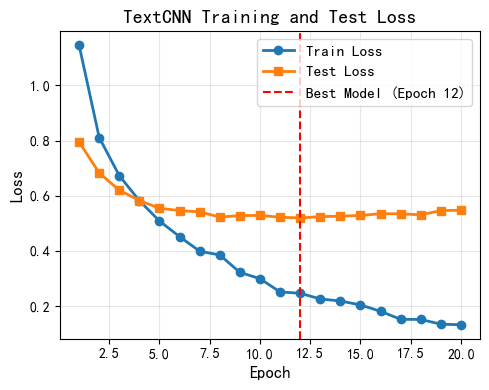


=== TextCNN Model (Best Epoch) ===
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       146
           1       0.88      0.68      0.77       154
           2       0.79      0.88      0.83       343
           3       0.69      0.70      0.69       191

    accuracy                           0.79       834
   macro avg       0.81      0.78      0.79       834
weighted avg       0.80      0.79      0.79       834

Accuracy: 0.7950
Weighted F1-score: 0.7939


In [237]:
# 准备数据
X = df['segmented_text'].values
y = df['topic_id'].values

# 过滤未分配主题的样本
mask = y != -1
X = X[mask]
y = y[mask]

print(f"样本总数: {len(X)}")
print(f"类别分布:\n{pd.Series(y).value_counts()}")

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 构建词汇表
vocab = Counter()
for text in X_train:
    vocab.update(text.split())

# 只保留出现次数>=2的词，并创建词到索引的映射
vocab_dict = {'<PAD>': 0}
for word, count in vocab.items():
    if count >= 2:
        vocab_dict[word] = len(vocab_dict)

vocab_size = len(vocab_dict)
print(f"词汇表大小: {vocab_size}")

# 文本转序列
def text_to_sequence(text, vocab_dict, max_len=100):
    words = text.split()
    seq = []
    for word in words[:max_len]:
        seq.append(vocab_dict.get(word, 0))
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))
    return seq

max_len = 100
X_train_seq = [text_to_sequence(text, vocab_dict, max_len) for text in X_train]
X_test_seq = [text_to_sequence(text, vocab_dict, max_len) for text in X_test]

# 转换为tensor
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 创建数据集
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train_tensor, y_train_tensor)
test_dataset = TextDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 定义TextCNN模型
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, num_filters=64, filter_sizes=[2,3,4], dropout=0.5):
        super(TextCNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, kernel_size=k) for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        
        conv_results = []
        for conv in self.convs:
            conv_out = torch.relu(conv(x))
            pooled = torch.max_pool1d(conv_out, conv_out.size(2)).squeeze(2)
            conv_results.append(pooled)
        
        x = torch.cat(conv_results, dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# 创建模型
embedding_dim = 100
num_classes = len(np.unique(y))
model = TextCNN(vocab_size, embedding_dim, num_classes, num_filters=64, filter_sizes=[2,3,4], dropout=0.5)
model = model.to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"模型参数量: {sum(p.numel() for p in model.parameters())}")
print(f"类别数: {num_classes}")

# 训练并记录损失
print("\n开始训练TextCNN...")
train_losses = []
test_losses = []
best_test_loss = float('inf')
best_epoch = 0
epochs = 20

for epoch in range(epochs):
    # 训练阶段
    model.train()
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 测试阶段
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_test_loss += loss.item()
    
    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # 保存最佳模型
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_textcnn_model.pth')
    
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')

print(f"\n最佳模型在第 {best_epoch} 个epoch，测试损失: {best_test_loss:.4f}")

# 加载最佳模型
model.load_state_dict(torch.load('best_textcnn_model.pth'))

# 绘制训练损失和测试损失对比图
plt.figure(figsize=(5, 4))
plt.plot(range(1, epochs + 1), train_losses, 'o-', label='Train Loss', linewidth=2, markersize=6)
plt.plot(range(1, epochs + 1), test_losses, 's-', label='Test Loss', linewidth=2, markersize=6)
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch})')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('TextCNN Training and Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('textcnn_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 评估最佳模型
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch_y.numpy())

# 保存TextCNN的结果
textcnn_acc = accuracy_score(true_labels, predictions)
textcnn_f1 = f1_score(true_labels, predictions, average='weighted')

print("\n=== TextCNN Model (Best Epoch) ===")
print(classification_report(true_labels, predictions))
print(f'Accuracy: {textcnn_acc:.4f}')
print(f'Weighted F1-score: {textcnn_f1:.4f}')

## 6.Comparison

In [238]:
# ==================== 结果对比（包含TextCNN） ====================
print("\n" + "="*100)
print("所有模型结果对比 (Accuracy & Weighted F1-score)")
print("="*100)

# 创建结果字典，同时存储Accuracy和F1（包含TextCNN）
results_acc = {
    'Logistic Regression': metrics.accuracy_score(y_test, y_pred_lr),
    'Naive Bayes': metrics.accuracy_score(y_test, y_pred_nb),
    'SVM': metrics.accuracy_score(y_test, y_pred_svm),
    'TextCNN': textcnn_acc,
    'Hard Voting (3 models)': metrics.accuracy_score(y_test, y_pred_hard),
    'Soft Voting (3 models)': metrics.accuracy_score(y_test, y_pred_soft),
    'Weighted Voting (3 models)': metrics.accuracy_score(y_test, y_pred_weighted),
    'Stacking (Meta: LR)': metrics.accuracy_score(y_test, y_pred_stacking_lr),
    'Stacking (Meta: NB)': metrics.accuracy_score(y_test, y_pred_stacking_nb),
    'Stacking (Meta: SVM)': metrics.accuracy_score(y_test, y_pred_stacking_svm),
    'Hard Voting (LR+SVM)': metrics.accuracy_score(y_test, y_pred_two_hard),
    'Soft Voting (LR+SVM)': metrics.accuracy_score(y_test, y_pred_two_soft),
    'Stacking (LR+SVM, Meta: LR)': metrics.accuracy_score(y_test, y_pred_stacking_two)
}

results_f1 = {
    'Logistic Regression': metrics.f1_score(y_test, y_pred_lr, average='weighted'),
    'Naive Bayes': metrics.f1_score(y_test, y_pred_nb, average='weighted'),
    'SVM': metrics.f1_score(y_test, y_pred_svm, average='weighted'),
    'TextCNN': textcnn_f1,
    'Hard Voting (3 models)': metrics.f1_score(y_test, y_pred_hard, average='weighted'),
    'Soft Voting (3 models)': metrics.f1_score(y_test, y_pred_soft, average='weighted'),
    'Weighted Voting (3 models)': metrics.f1_score(y_test, y_pred_weighted, average='weighted'),
    'Stacking (Meta: LR)': metrics.f1_score(y_test, y_pred_stacking_lr, average='weighted'),
    'Stacking (Meta: NB)': metrics.f1_score(y_test, y_pred_stacking_nb, average='weighted'),
    'Stacking (Meta: SVM)': metrics.f1_score(y_test, y_pred_stacking_svm, average='weighted'),
    'Hard Voting (LR+SVM)': metrics.f1_score(y_test, y_pred_two_hard, average='weighted'),
    'Soft Voting (LR+SVM)': metrics.f1_score(y_test, y_pred_two_soft, average='weighted'),
    'Stacking (LR+SVM, Meta: LR)': metrics.f1_score(y_test, y_pred_stacking_two, average='weighted')
}

# 打印表头
print(f"{'Model':<35s} {'Accuracy':<12s} {'Weighted F1':<12s}")
print("-" * 100)

# 合并并排序（按Accuracy排序）
all_models = sorted(results_acc.keys(), key=lambda x: results_acc[x], reverse=True)

for model in all_models:
    acc = results_acc[model]
    f1 = results_f1[model]
    print(f"{model:<35s} {acc:<12.4f} {f1:<12.4f}")

print("="*100)

# 找出最佳模型
best_acc_model = max(results_acc, key=results_acc.get)
best_f1_model = max(results_f1, key=results_f1.get)

print(f"\n最佳Accuracy模型: {best_acc_model} (Accuracy: {results_acc[best_acc_model]:.4f})")
print(f"最佳F1-score模型: {best_f1_model} (F1-score: {results_f1[best_f1_model]:.4f})")


所有模型结果对比 (Accuracy & Weighted F1-score)
Model                               Accuracy     Weighted F1 
----------------------------------------------------------------------------------------------------
Stacking (LR+SVM, Meta: LR)         0.8441       0.8447      
Soft Voting (3 models)              0.8429       0.8433      
Stacking (Meta: SVM)                0.8429       0.8435      
Weighted Voting (3 models)          0.8417       0.8421      
Stacking (Meta: LR)                 0.8417       0.8424      
Soft Voting (LR+SVM)                0.8417       0.8424      
Hard Voting (3 models)              0.8381       0.8377      
Stacking (Meta: NB)                 0.8381       0.8388      
Hard Voting (LR+SVM)                0.8357       0.8345      
SVM                                 0.8345       0.8353      
Logistic Regression                 0.8285       0.8281      
Naive Bayes                         0.8237       0.8227      
TextCNN                             0.7950       0.7

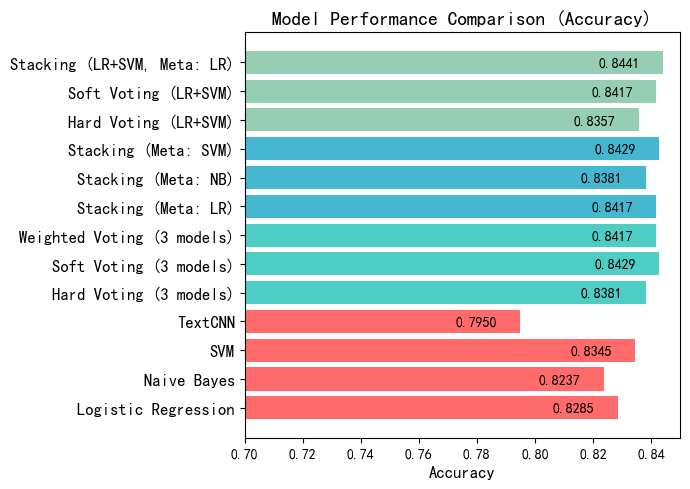

In [239]:
# 可视化
plt.figure(figsize=(7, 5))

# 使用results_acc作为可视化数据（包含TextCNN）
names = list(results_acc.keys())
scores = list(results_acc.values())

# 根据模型类型分配颜色
color_map = []
for name in names:
    # 第一类：单一模型（Logistic Regression, Naive Bayes, SVM, TextCNN）
    if name in ['Logistic Regression', 'Naive Bayes', 'SVM', 'TextCNN']:
        color_map.append('#FF6B6B')  # 红色
    # 第二类：3模型投票集成
    elif name in ['Hard Voting (3 models)', 'Soft Voting (3 models)', 'Weighted Voting (3 models)']:
        color_map.append('#4ECDC4')  # 青色
    # 第三类：3模型Stacking集成
    elif name in ['Stacking (Meta: LR)', 'Stacking (Meta: NB)', 'Stacking (Meta: SVM)']:
        color_map.append('#45B7D1')  # 蓝色
    # 第四类：LR+SVM集成
    elif name in ['Hard Voting (LR+SVM)', 'Soft Voting (LR+SVM)', 'Stacking (LR+SVM, Meta: LR)']:
        color_map.append('#96CEB4')  # 绿色
    else:
        color_map.append('#E8E8E8')  # 灰色

plt.barh(names, scores, color=color_map)
plt.xlabel('Accuracy', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Model Performance Comparison (Accuracy)', fontsize=14, fontweight='bold')
plt.xlim(0.7, 0.85)

# 数字标签放在柱状图内部靠右边
for i, (name, score) in enumerate(results_acc.items()):
    plt.text(score - 0.008, i, f'{score:.4f}', 
            va='center', ha='right', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()